# 1. Let Load the dataset of a uav with different timestamp

In [1]:
import pandas as pd
df = pd.read_excel("uav_path.xlsx")
print(df.iloc[:, :6])
print(df.shape)


    CUSTOM.date [local] CUSTOM.updateTime [local] OSD.flyTime  \
0            10/27/2025           12:12:19.480000     0m 0.0s   
1            10/27/2025           12:12:19.580000     0m 0.1s   
2            10/27/2025           12:12:19.680000     0m 0.2s   
3            10/27/2025           12:12:19.760000     0m 0.3s   
4            10/27/2025           12:12:19.880000     0m 0.4s   
..                  ...                       ...         ...   
858          10/27/2025           12:13:45.260000    1m 25.8s   
859          10/27/2025           12:13:45.360000    1m 25.9s   
860          10/27/2025           12:13:45.460000    1m 26.0s   
861          10/27/2025           12:13:45.560000    1m 26.1s   
862          10/27/2025           12:13:45.630000    1m 26.2s   

     OSD.flyTime [s]  OSD.latitude  OSD.longitude  
0                0.0     30.771072     103.984368  
1                0.1     30.771072     103.984368  
2                0.2     30.771072     103.984368  
3          

# 2. select useful column for our model

In [2]:
for i, col in enumerate(df.columns):
    print(i, col)


0 CUSTOM.date [local]
1 CUSTOM.updateTime [local]
2 OSD.flyTime
3 OSD.flyTime [s]
4 OSD.latitude
5 OSD.longitude
6 OSD.height [ft]
7 OSD.heightMax [ft]
8 OSD.vpsHeight [ft]
9 OSD.altitude [ft]
10 OSD.mileage [ft]
11 OSD.hSpeed [MPH]
12 OSD.hSpeedMax [MPH]
13 OSD.xSpeed [MPH]
14 OSD.xSpeedMax [MPH]
15 OSD.ySpeed [MPH]
16 OSD.ySpeedMax [MPH]
17 OSD.zSpeed [MPH]
18 OSD.zSpeedMax [MPH]
19 OSD.pitch
20 OSD.roll
21 OSD.yaw
22 OSD.yaw [360]
23 OSD.directionOfTravel
24 OSD.flycState
25 OSD.flycCommand
26 OSD.flightAction
27 OSD.gpsNum
28 OSD.gpsLevel
29 OSD.isGPSUsed
30 OSD.nonGPSCause
31 OSD.droneType
32 OSD.isSwaveWork
33 OSD.waveError
34 OSD.goHomeStatus
35 OSD.batteryType
36 OSD.ctrlDevice
37 OSD.isOnGround
38 OSD.isMotorOn
39 OSD.isMotorBlocked
40 OSD.motorStartFailedCause
41 OSD.motorFailReason
42 OSD.isImuPreheated
43 OSD.imuInitFailReason
44 OSD.isAcceletorOverRange
45 OSD.isBarometerDeadInAir
46 OSD.isCompassError
47 OSD.isGoHomeHeightModified
48 OSD.canIOCWork
49 OSD.isNotEnoughForce

In [3]:
cols_needed = [
    "OSD.flyTime [s]",
    "OSD.latitude",
    "OSD.longitude",
    "OSD.altitude [ft]",
    "OSD.hSpeed [MPH]",
    "OSD.zSpeed [MPH]",
    "OSD.yaw"
]

df1 = df[cols_needed].copy()



In [4]:
df1.shape

(863, 7)

In [5]:
df1.head()

,OSD.flyTime [s],OSD.latitude,OSD.longitude,OSD.altitude [ft],OSD.hSpeed [MPH],OSD.zSpeed [MPH],OSD.yaw
0,0.0,30.771072,103.984368,1721,0.0,0.0,-38.5
1,0.1,30.771072,103.984368,1721,0.0,0.0,-38.5
2,0.2,30.771072,103.984368,1721,0.0,0.0,-38.5
3,0.3,30.771072,103.984368,1721,0.0,0.0,-38.5
4,0.4,30.771072,103.984368,1721,0.0,0.0,-38.5


In [6]:
print(df["OSD.latitude"].iloc[0])


30.7710723122455


## 3.Clean the data - remove null and sorting base on timestamp

In [7]:
df1 = df1.dropna()
df1 = df1.sort_values("OSD.flyTime [s]")
df1 = df1.reset_index(drop=True)


In [8]:
df1.shape

(863, 7)

## 4. Unit conversion- feet->meter,MPH->m/s,encode yaw properly

In [9]:
df1["altitude_m"] = df1["OSD.altitude [ft]"] * 0.3048
df1["hSpeed_mps"] = df1["OSD.hSpeed [MPH]"] * 0.44704
df1["zSpeed_mps"] = df1["OSD.zSpeed [MPH]"] * 0.44704

In [10]:
df1.head()

,OSD.flyTime [s],OSD.latitude,OSD.longitude,OSD.altitude [ft],OSD.hSpeed [MPH],OSD.zSpeed [MPH],OSD.yaw,altitude_m,hSpeed_mps,zSpeed_mps
0,0.0,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0
1,0.1,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0
2,0.2,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0
3,0.3,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0
4,0.4,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0


In [11]:
import numpy as np

yaw_rad = np.deg2rad(df1["OSD.yaw"])
df1["yaw_sin"] = np.sin(yaw_rad)
df1["yaw_cos"] = np.cos(yaw_rad)


In [12]:
df1.head()

,OSD.flyTime [s],OSD.latitude,OSD.longitude,OSD.altitude [ft],OSD.hSpeed [MPH],OSD.zSpeed [MPH],OSD.yaw,altitude_m,hSpeed_mps,zSpeed_mps,yaw_sin,yaw_cos
0,0.0,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0,-0.622515,0.782608
1,0.1,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0,-0.622515,0.782608
2,0.2,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0,-0.622515,0.782608
3,0.3,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0,-0.622515,0.782608
4,0.4,30.771072,103.984368,1721,0.0,0.0,-38.5,524.5608,0.0,0.0,-0.622515,0.782608


## 5. Build feature matrix

In [13]:
features = [
    "OSD.latitude",
    "OSD.longitude",
    "altitude_m",
    "hSpeed_mps",
    "zSpeed_mps",
    "yaw_sin",
    "yaw_cos"
]

data = df1[features].values
data


array([[ 30.77107231, 103.98436767, 524.5608    , ...,   0.        ,
         -0.62251464,   0.78260816],
       [ 30.7710723 , 103.98436765, 524.5608    , ...,   0.        ,
         -0.62251464,   0.78260816],
       [ 30.77107229, 103.98436765, 524.5608    , ...,   0.        ,
         -0.62251464,   0.78260816],
       ...,
       [ 30.77107817, 103.98435108, 524.5608    , ...,   0.        ,
         -0.58354121,   0.81208353],
       [ 30.77107821, 103.98435106, 524.5608    , ...,   0.        ,
         -0.58354121,   0.81208353],
       [ 30.77107822, 103.98435107, 524.5608    , ...,   0.        ,
         -0.58354121,   0.81208353]])

## 6. Normalize the data

In [14]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)


## 7. Create sliding window sequence:
        X -> past 15 timesteps
        y -> next position(lat,lon)

In [15]:
SEQ_LEN = 15
TARGET_COLS = [0,1]

X, y = [], []

for i in range(len(data_scaled) - SEQ_LEN):
    X.append(data_scaled[i:i+SEQ_LEN])
    y.append(data_scaled[i+SEQ_LEN,TARGET_COLS])

X = np.array(X)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)


X shape: (848, 15, 7)
y shape: (848, 2)


In [16]:
print("X[0]:\n", X[0])
print("\ny[0]:\n", y[0])


X[0]:
 [[0.48317376 0.99769274 0.         0.         0.53846154 0.
  0.        ]
 [0.4828564  0.99744483 0.         0.         0.53846154 0.
  0.        ]
 [0.48277798 0.99745213 0.         0.         0.53846154 0.
  0.        ]
 [0.48256512 0.99714294 0.         0.         0.53846154 0.
  0.        ]
 [0.48260358 0.99705288 0.         0.         0.53846154 0.
  0.        ]
 [0.48290723 0.99714098 0.         0.         0.53846154 0.
  0.        ]
 [0.48305755 0.99695276 0.         0.         0.53846154 0.03269078
  0.03444593]
 [0.48318666 0.99790073 0.         0.         0.53846154 0.09820799
  0.10311039]
 [0.48335118 0.99801378 0.         0.         0.53846154 0.16390542
  0.17147094]
 [0.48284326 0.99787379 0.         0.         0.53846154 0.16390542
  0.17147094]
 [0.48281376 0.9978751  0.         0.         0.53846154 0.16390542
  0.17147094]
 [0.4825586  0.99758641 0.         0.         0.53846154 0.26278772
  0.2734401 ]
 [0.48239969 0.9973723  0.         0.         0.53846154 

## 8. Train-test split without shuffle

In [17]:
split = int(0.8 * len(X))

X_train = X[:split]
X_test  = X[split:]

y_train = y[:split]
y_test  = y[split:]

print(X_train.shape, X_test.shape)

(678, 15, 7) (170, 15, 7)


## 9.Build LSTM model

In [18]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64,input_shape=(SEQ_LEN, X.shape[2])),
    Dense(32, activation='relu'),
    Dense(2)
])

model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

model.summary()

/opt/anaconda3/envs/uav/lib/python3.12/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,578 (80.38 KB)

 Trainable params: 20,578 (80.38 KB)

 Non-trainable params: 0 (0.00 B)

## 10.Train the model 

In [19]:
history = model.fit(
    X_train, y_train,
    epochs=80,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1
)

Epoch 1/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0630 - mae: 0.1890 - val_loss: 0.0132 - val_mae: 0.1010
Epoch 2/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0091 - mae: 0.0629 - val_loss: 0.0012 - val_mae: 0.0249
Epoch 3/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0044 - mae: 0.0404 - val_loss: 0.0021 - val_mae: 0.0339
Epoch 4/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0030 - mae: 0.0339 - val_loss: 0.0015 - val_mae: 0.0287
Epoch 5/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022 - mae: 0.0296 - val_loss: 0.0019 - val_mae: 0.0330
Epoch 6/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0018 - mae: 0.0268 - val_loss: 0.0010 - val_mae: 0.0235
Epoch 7/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0015 - mae: 0.0255 - val_loss: 0.0019 - val_mae: 0.0384
Epoch 8/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0013 - mae: 0.0237 - val_loss: 0.0012 - val_mae: 0.0240
Epoch 9/80
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0012 - mae: 

In [20]:
loss, mae = model.evaluate(X_test, y_test)
print("Test MAE:", mae)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 2.1215e-04 - mae: 0.0098
Test MAE: 0.009832390584051609


In [21]:
y_pred = model.predict(X_test)

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


In [22]:
def inverse_latlon(scaled_latlon, scaler):
    temp = np.zeros((scaled_latlon.shape[0], 7))
    temp[:, :2] = scaled_latlon
    inv = scaler.inverse_transform(temp)
    return inv[:, :2]

y_test_inv = inverse_latlon(y_test, scaler)
y_pred_inv = inverse_latlon(y_pred, scaler)

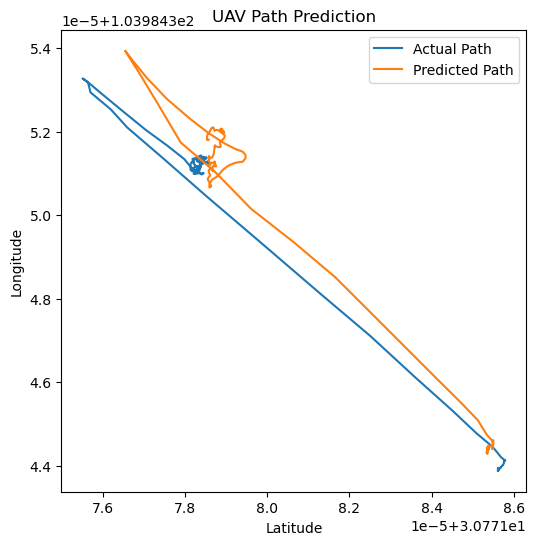

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

plt.plot(
    y_test_inv[:,0], 
    y_test_inv[:,1],  
    label="Actual Path"
)

plt.plot(
    y_pred_inv[:,0],
    y_pred_inv[:,1],
    label="Predicted Path"
)

plt.legend()
plt.xlabel("Latitude")
plt.ylabel("Longitude")
plt.title("UAV Path Prediction")
plt.show()

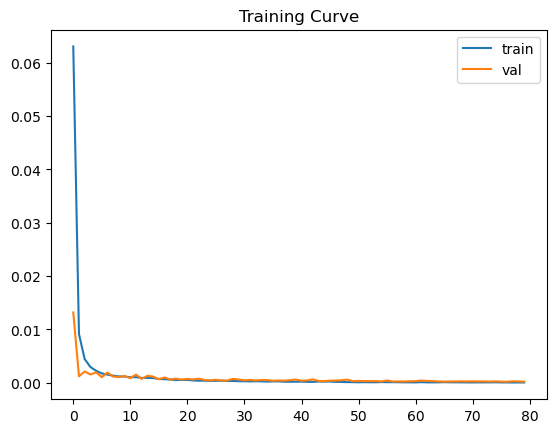

In [24]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("Training Curve")
plt.show()

In [25]:
actual_coords = y_test_inv[:, :2].tolist()
pred_coords = y_pred_inv[:, :2].tolist()
lat0, lon0 = actual_coords[0]

In [26]:
def stretch_path(coords, factor=100):
    """
    Stretch small trajectories for visualization only.
    factor > 1 enlarges the path.
    """
    base_lat, base_lon = coords[0]
    stretched = []

    for lat, lon in coords:
        new_lat = base_lat + (lat - base_lat) * factor
        new_lon = base_lon + (lon - base_lon) * factor
        stretched.append([new_lat, new_lon])

    return stretched

In [27]:
import folium
import numpy as np

# ===============================
# 1. Build coordinate lists
# ===============================
actual_coords = y_test_inv[:, :2].tolist()
pred_coords   = y_pred_inv[:, :2].tolist()

# stretch only for display
actual_coords_vis = stretch_path(actual_coords, factor=50)
pred_coords_vis   = stretch_path(pred_coords, factor=50)


# ===============================
# 2. Map center
# ===============================
lat0, lon0 = actual_coords[0]

m = folium.Map(
    location=[lat0, lon0],
    zoom_start=18,
    control_scale=True
)

# ===============================
# 3. Draw actual path (BLUE)
# ===============================
folium.PolyLine(
    actual_coords_vis,
    color="blue",
    weight=5,
    opacity=0.8,
    tooltip="Actual UAV Path"
).add_to(m)

# ===============================
# 4. Draw predicted path (RED)
# ===============================
folium.PolyLine(
    pred_coords_vis,
    color="red",
    weight=5,
    opacity=0.8,
    tooltip="Predicted UAV Path"
).add_to(m)

# ===============================
# 5. Start & End markers
# ===============================
folium.Marker(
    actual_coords_vis[0],
    tooltip="Start",
    icon=folium.Icon(color="green")
).add_to(m)

folium.Marker(
    actual_coords_vis[-1],
    tooltip="Actual End",
    icon=folium.Icon(color="blue")
).add_to(m)

folium.Marker(
    pred_coords_vis[-1],
    tooltip="Predicted End",
    icon=folium.Icon(color="red")
).add_to(m)

# ===============================
# 6. Auto-fit map to data (VERY IMPORTANT)
# ===============================
m.fit_bounds(actual_coords_vis + pred_coords_vis)

# ===============================
# 7. Display map
# ===============================
m